<a href="https://colab.research.google.com/github/cdmafAdi/computer_vision_lecture_notes/blob/main/chp_no-3%20image_vision/7_without_finetunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
/root/.keras/datasets/flower_photos


In [2]:


IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

In [25]:
o_data_dir = '/root/.keras/datasets/flower_photos/flower_photos'
train_ds = tf.keras.utils.image_dataset_from_directory(
    o_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [26]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    o_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32,
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [27]:
for image_batch, label_batch in train_ds.take(3):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [2 1 4 3 1 2 1 2 4 1 4 4 3 4 1 2 0 4 1 1 1 4 3 2 3 1 4 2 2 3 4 3]
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [0 2 4 4 4 1 1 1 1 1 3 0 1 2 4 0 3 1 0 0 4 4 4 2 4 1 1 0 4 3 2 0]
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [4 0 2 4 1 2 2 4 0 0 1 3 4 3 4 4 4 3 0 3 4 3 0 0 1 2 0 1 1 4 1 1]


In [28]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (128,128,3),
    include_top = False, # remove classification head
    weights = 'imagenet'
)

# 2 frezee base model

In [29]:
base_model.trainable = False

**3. adding new calssification head**

In [30]:
model = tf.keras.Sequential([
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.BatchNormalization(),       # Add BatchNorm
            tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])

In [41]:
model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"]
        )

In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [43]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file="model_visualization.png")
callbacks=[
          tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss')
      ]



In [44]:
from IPython.core import history
history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True,monitor='val_loss')
          ]
        )

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.6706 - loss: 0.8912 - val_accuracy: 0.5123 - val_loss: 1.5019
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6655 - loss: 0.8848 - val_accuracy: 0.5095 - val_loss: 1.5693
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6693 - loss: 0.8872 - val_accuracy: 0.5095 - val_loss: 1.6298


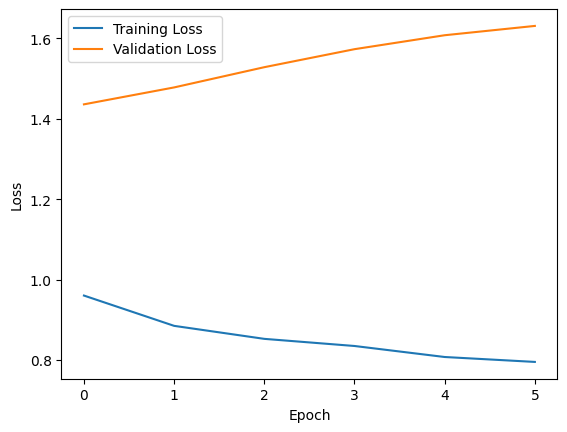

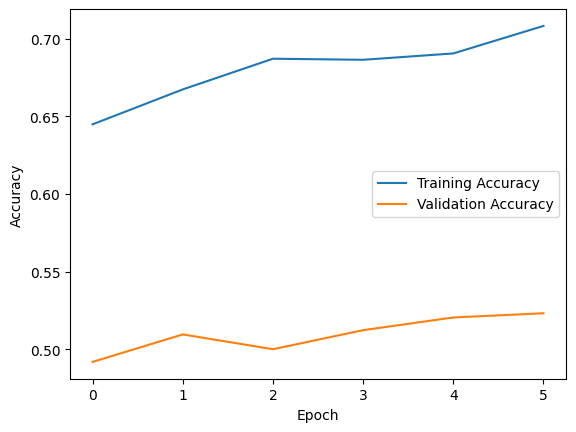

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

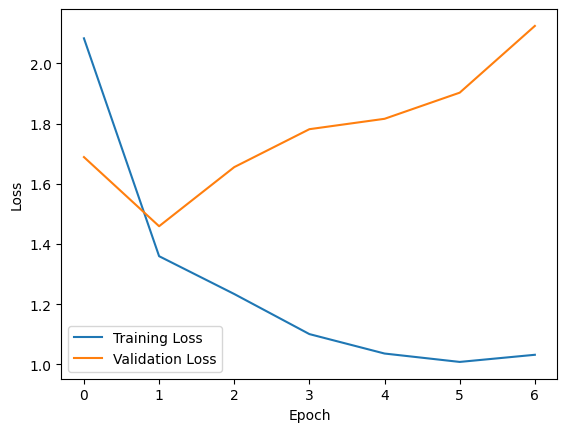

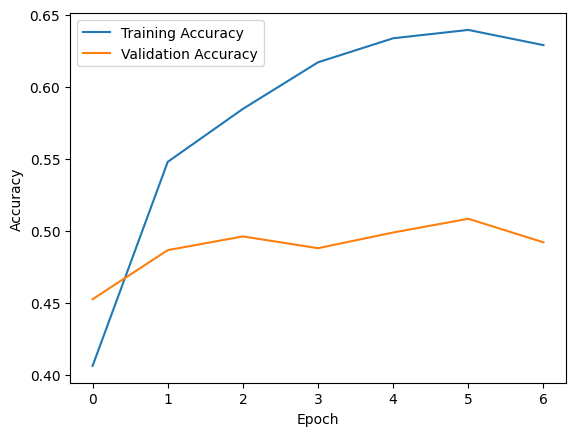

In [35]:


import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()